In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("Netflix.csv")

In [26]:
print("numero de filas y columnas: ",df.shape)
print()
print(df.info())
print()
df.sample(3)

numero de filas y columnas:  (5283, 11)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5283 entries, 0 to 5282
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              5283 non-null   int64  
 1   id                 5283 non-null   object 
 2   title              5283 non-null   object 
 3   type               5283 non-null   object 
 4   description        5278 non-null   object 
 5   release_year       5283 non-null   int64  
 6   age_certification  2998 non-null   object 
 7   runtime            5283 non-null   int64  
 8   imdb_id            5283 non-null   object 
 9   imdb_score         5283 non-null   float64
 10  imdb_votes         5267 non-null   float64
dtypes: float64(2), int64(3), object(6)
memory usage: 454.1+ KB
None



,index,id,title,type,description,release_year,age_certification,runtime,imdb_id,imdb_score,imdb_votes
267,267,tm139658,Big Fish,MOVIE,Throughout his life Edward Bloom has always be...,2003,PG-13,125,tt0319061,8.0,435503.0
639,639,tm142153,Kisaan,MOVIE,A bitter family battle ensues between a father...,2009,NaN,100,tt1372266,5.5,302.0
1726,1726,tm232797,Dunkirk,MOVIE,The story of the miraculous evacuation of Alli...,2017,PG-13,107,tt5013056,7.8,619645.0


In [40]:
print(df.describe())

print(df.describe(include=object))

             index  release_year      runtime   imdb_score    imdb_votes
count  5283.000000   5283.000000  5283.000000  5283.000000  5.267000e+03
mean   2641.000000   2015.879992    79.199886     6.533447  2.340719e+04
std    1525.215067      7.346098    38.915974     1.160932  8.713432e+04
min       0.000000   1953.000000     0.000000     1.500000  5.000000e+00
25%    1320.500000   2015.000000    45.000000     5.800000  5.210000e+02
50%    2641.000000   2018.000000    87.000000     6.600000  2.279000e+03
75%    3961.500000   2020.000000   106.000000     7.400000  1.014400e+04
max    5282.000000   2022.000000   235.000000     9.600000  2.268288e+06
              id     title   type  \
count       5283      5283   5283   
unique      5283      5237      2   
top     ts271048  The Gift  MOVIE   
freq           1         3   3407   

                                              description age_certification  \
count                                                5278              2998   

In [23]:
df.head(5)

,index,id,title,type,description,release_year,age_certification,runtime,imdb_id,imdb_score,imdb_votes
0,0,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,113,tt0075314,8.3,795222.0
1,1,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,tt0071853,8.2,530877.0
2,2,tm70993,Life of Brian,MOVIE,"Brian Cohen is an average young Jewish man, bu...",1979,R,94,tt0079470,8.0,392419.0
3,3,tm190788,The Exorcist,MOVIE,12-year-old Regan MacNeil begins to adapt an e...,1973,R,133,tt0070047,8.1,391942.0
4,4,ts22164,Monty Python's Flying Circus,SHOW,A British sketch comedy series with the shows ...,1969,TV-14,30,tt0063929,8.8,72895.0


PERFIL DE NULOS

In [22]:
print(df.isna().sum())
print()
print(df.isna().mean().sort_values(ascending=False)*100)
print()
print("filas con na", df.isna().any(axis=1).sum())
print("filas con na", df.isna().any(axis=1).mean())

index                   0
id                      0
title                   0
type                    0
description             5
release_year            0
age_certification    2285
runtime                 0
imdb_id                 0
imdb_score              0
imdb_votes             16
dtype: int64

age_certification    43.251940
imdb_votes            0.302858
description           0.094643
title                 0.000000
id                    0.000000
index                 0.000000
type                  0.000000
release_year          0.000000
runtime               0.000000
imdb_id               0.000000
imdb_score            0.000000
dtype: float64

filas con na 2296
filas con na 0.4346015521484005


PERFIL CATEGORICO

In [30]:
categorical=df.select_dtypes(include=object)
categorical.apply(lambda x:x.unique())
print(categorical.apply(lambda x:x.nunique()))

id                   5283
title                5237
type                    2
description          5276
age_certification      11
imdb_id              5283
dtype: int64


PERFIL DUPLICADOS

In [38]:
print(df.duplicated().sum())
duplicates=df[df.duplicated()]
print(duplicates.shape)

0
(0, 11)


CAST

In [65]:
df_cast=df.copy().assign(
    id= lambda d: (d["id"].astype(str).str.strip().str.upper()),
    title= lambda d: (d["title"].astype(str).str.strip().str.upper()),
    type= lambda d: (d["type"].astype(str).str.strip().str.upper()),
    age_certification= lambda d: (d["age_certification"].fillna("UNKNOWN").astype(str).str.strip().str.upper()),
    imdb_id= lambda d: (d["imdb_id"].astype(str).str.strip().str.upper()),
    description= lambda d:(d["description"].fillna("NO DESCRIPTION").astype(str).str.strip().str.upper()),
    imdb_votes=lambda d:(d["imdb_votes"].fillna(d["imdb_votes"].median()))
    
)
df_cast = df_cast.drop(columns="index")

In [66]:
print(df_cast.info())
print(df_cast.isna().sum())
print()
print(df_cast.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5283 entries, 0 to 5282
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5283 non-null   object 
 1   title              5283 non-null   object 
 2   type               5283 non-null   object 
 3   description        5283 non-null   object 
 4   release_year       5283 non-null   int64  
 5   age_certification  5283 non-null   object 
 6   runtime            5283 non-null   int64  
 7   imdb_id            5283 non-null   object 
 8   imdb_score         5283 non-null   float64
 9   imdb_votes         5283 non-null   float64
dtypes: float64(2), int64(2), object(6)
memory usage: 412.9+ KB
None
id                   0
title                0
type                 0
description          0
release_year         0
age_certification    0
runtime              0
imdb_id              0
imdb_score           0
imdb_votes           0
dtype: int64

0


In [67]:
print(df_cast["type"].value_counts())
print()
print(df_cast["age_certification"].value_counts())

type
MOVIE    3407
SHOW     1876
Name: count, dtype: int64

age_certification
UNKNOWN    2285
TV-MA       792
R           548
TV-14       436
PG-13       424
PG          238
TV-PG       172
G           105
TV-Y7       104
TV-Y         94
TV-G         72
NC-17        13
Name: count, dtype: int64


PERFIL OUTLIERS

In [71]:
q1,q3=df_cast["runtime"].quantile([0.25,0.75])
iqr=q3-q1
low,high= q1-1.5*iqr,q3+1.5*iqr
outliers=df_cast.loc[~df_cast["runtime"].between(low,high)]
outliers

,id,title,type,description,release_year,age_certification,runtime,imdb_id,imdb_score,imdb_votes
24,TM76557,NO LONGER KIDS,MOVIE,"BY COINCIDENCE, AHMAD DISCOVERS THAT HIS FATHE...",1979,UNKNOWN,235,TT8312792,9.0,943.0
45,TM180542,ONCE UPON A TIME IN AMERICA,MOVIE,A FORMER PROHIBITION-ERA JEWISH GANGSTER RETUR...,1984,R,229,TT0087843,8.3,342335.0
201,TM117873,HUM AAPKE HAIN KOUN..!,MOVIE,PREM AND NISHA MEET AND FALL IN LOVE AT THE WE...,1994,UNKNOWN,206,TT0110076,7.5,20986.0
378,TM43399,LAGAAN: ONCE UPON A TIME IN INDIA,MOVIE,"IN 1890S INDIA, AN ARROGANT BRITISH COMMANDER ...",2001,PG,224,TT0169102,8.1,111053.0
423,TM36475,KABHI KHUSHI KABHIE GHAM,MOVIE,"RAHUL, THE ADOPTIVE SON OF BUSINESS MAGNATE YA...",2001,G,210,TT0248126,7.4,48818.0
428,TM29269,JODHAA AKBAR,MOVIE,JODHAA AKBAR IS A SIXTEENTH CENTURY LOVE STORY...,2008,PG-13,213,TT0449994,7.5,32188.0
495,TM25842,A LION IN THE HOUSE,MOVIE,FIVE FAMILIES STRUGGLE WITH THE UPS AND DOWNS ...,2006,UNKNOWN,225,TT0492472,8.7,312.0
3046,TM244149,THE IRISHMAN,MOVIE,"PENNSYLVANIA, 1956. FRANK SHEERAN, A WAR VETER...",2019,R,209,TT1302006,7.8,371209.0


In [72]:
df_cast[df_cast["runtime"] == 0]

,id,title,type,description,release_year,age_certification,runtime,imdb_id,imdb_score,imdb_votes
450,TS74931,KUNG FU PANDA AWESOME SECRETS,SHOW,"IN THIS PAIR OF ADVENTURES, PO TELLS THE STORY...",2008,UNKNOWN,0,TT6963796,7.2,55.0
455,TS98252,DREAMWORKS HAPPY HOLIDAYS FROM MADAGASCAR,SHOW,MADAGASCAR GOES WILD WITH HOLIDAY SPIRIT IN TH...,2005,TV-PG,0,TT6929194,6.5,96.0
535,TS67595,PEDRO EL ESCAMOSO,SHOW,PEDRO EL ESCAMOSO IS A POPULAR TELENOVELA FILM...,2001,TV-14,0,TT0283770,7.5,303.0
840,TS99814,MASAMEER,SHOW,A POPULAR SAUDI ANIMATION SHOW TALKS SARCASTIC...,2011,TV-MA,0,TT6298258,8.2,677.0
2503,TS74765,DAUGHTERS OF DESTINY,SHOW,FIVE GIRLS FROM INDIA'S MOST IMPOVERISHED FAMI...,2017,UNKNOWN,0,TT1877895,8.6,900.0
2996,TS250172,AFRONTA!,SHOW,AFRONTA INVITES CONTEMPORARY BLACK ARTISTS AND...,2017,TV-PG,0,TT12467250,7.4,8.0
3528,TS268592,BEYBLADE BURST RISE,SHOW,"BEYBLADE BURST RISE, ALSO KNOWN AS BEYBLADE BU...",2019,UNKNOWN,0,TT11916718,5.7,156.0
3733,TS217719,BASKETBALL OR NOTHING,SHOW,THE LIVES OF THE CHINLE HIGH SCHOOL BOYS' BASK...,2019,TV-PG,0,TT10698408,7.4,614.0
3743,TS255418,BAD BOY BILLIONAIRES: INDIA,SHOW,THIS INVESTIGATIVE DOCUSERIES EXPLORES THE GRE...,2020,TV-14,0,TT12923630,7.9,3010.0
3757,TS237071,THE FOREST OF LOVE: DEEP CUT,SHOW,NOTHING'S AS IT SEEMS WHEN A CHARISMATIC CONMA...,2020,TV-MA,0,TT12079236,6.8,426.0


In [74]:
df_cast.loc[df_cast["runtime"] == 0, "runtime"] = np.nan
df_cast["runtime"] = df_cast["runtime"].fillna(df_cast["runtime"].median())

In [75]:
df_cast.describe()

,release_year,runtime,imdb_score,imdb_votes
count,5283.000000,5283.000000,5283.000000,5.283000e+03
mean,2015.879992,79.496309,6.533447,2.334321e+04
std,7.346098,38.641903,1.160932,8.700999e+04
min,1953.000000,2.000000,1.500000,5.000000e+00
25%,2015.000000,46.000000,5.800000,5.220000e+02
50%,2018.000000,87.000000,6.600000,2.279000e+03
75%,2020.000000,106.000000,7.400000,1.009700e+04
max,2022.000000,235.000000,9.600000,2.268288e+06


<Axes: >

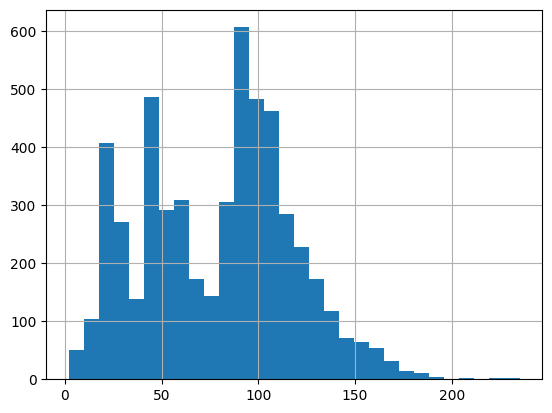

In [87]:
df_cast["runtime"].hist(bins=30)


<Axes: xlabel='runtime'>

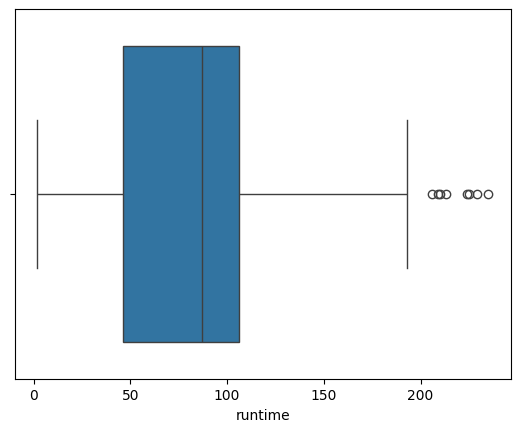

In [88]:
sns.boxplot(x=df_cast["runtime"])

In [84]:
df_cast[df_cast["runtime"] <= 20].groupby("type")["runtime"].value_counts()

type   runtime
MOVIE  8.0         2
       12.0        2
       13.0        2
       15.0        2
       9.0         1
       10.0        1
       14.0        1
       16.0        1
       20.0        1
SHOW   20.0       21
       11.0       18
       13.0       17
       12.0       15
       15.0       14
       19.0       12
       6.0        10
       17.0       10
       18.0        9
       5.0         7
       9.0         7
       10.0        7
       16.0        7
       3.0         6
       8.0         6
       14.0        6
       2.0         4
       7.0         4
       4.0         3
Name: count, dtype: int64

In [91]:
!pip install openpyxl

   ---------------------------------------- 0.0/250.9 kB ? eta -:--:--
   ------ -------------------------------- 41.0/250.9 kB 793.4 kB/s eta 0:00:01
   ---------------- ----------------------- 102.4/250.9 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------  245.8/250.9 kB 1.8 MB/s eta 0:00:01
   ---------------------------------------- 250.9/250.9 kB 1.5 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [92]:
df_cast.to_excel("netflix_clean.xlsx", index=False)

In [128]:
# promedio score por tipo
type_to_score = df_cast.groupby("type")["imdb_score"].mean()
# cantidad movies vs shows
movies_vs_shows = df_cast["type"].value_counts()
# contenido por año
contenido_tiempo = df_cast["release_year"].value_counts().sort_index()
# distribución runtime
runtime_dist = df_cast["runtime"].value_counts().sort_index()
# score por clasificación de edad
calidad_contenido = (
    df_cast.groupby("age_certification")["imdb_score"]
    .mean()
    .sort_values(ascending=False)
)
print(type_to_score)
print(movies_vs_shows)
print(contenido_tiempo)
print(runtime_dist)
print(calidad_contenido)

type
MOVIE    6.266980
SHOW     7.017377
Name: imdb_score, dtype: float64
type
MOVIE    3407
SHOW     1876
Name: count, dtype: int64
release_year
1953      1
1954      2
1956      1
1958      1
1959      1
       ... 
2018    733
2019    749
2020    657
2021    687
2022    182
Name: count, Length: 66, dtype: int64
runtime
2.0       4
3.0       6
4.0       3
5.0       7
6.0      10
         ..
213.0     1
224.0     1
225.0     1
229.0     1
235.0     1
Name: count, Length: 196, dtype: int64
age_certification
TV-14      7.262615
TV-MA      7.065909
TV-PG      6.916860
TV-Y7      6.913462
TV-Y       6.547872
PG-13      6.444575
NC-17      6.400000
G          6.393333
TV-G       6.348611
R          6.321168
UNKNOWN    6.277287
PG         6.208403
Name: imdb_score, dtype: float64


In [129]:
#¿Las películas más votadas también tienen mejor score?
popularidad_vs_calidad = df_cast[["imdb_votes","imdb_score"]].corr()
print(popularidad_vs_calidad)

            imdb_votes  imdb_score
imdb_votes    1.000000    0.189679
imdb_score    0.189679    1.000000


release_year
1953    6.800000
1954    7.450000
1956    6.700000
1958    7.500000
1959    6.700000
          ...   
2018    6.530559
2019    6.526168
2020    6.344444
2021    6.319068
2022    6.263187
Name: imdb_score, Length: 66, dtype: float64


<Axes: xlabel='release_year'>

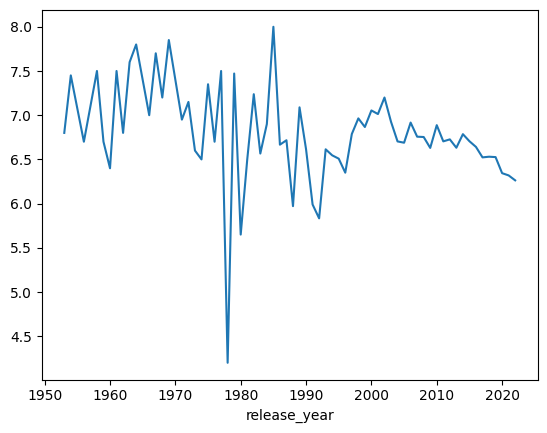

In [130]:
#¿El contenido nuevo tiene mejor calidad?
score_por_año = df_cast.groupby("release_year")["imdb_score"].mean()
print(score_por_año)
score_por_año.plot()

             runtime  imdb_score
runtime     1.000000   -0.155984
imdb_score -0.155984    1.000000


<Axes: xlabel='runtime', ylabel='imdb_score'>

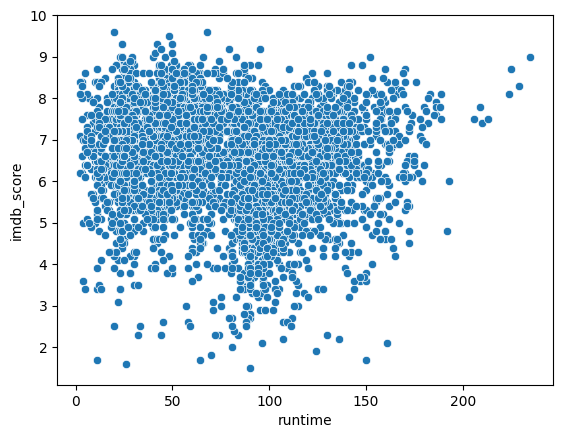

In [131]:
#¿Las películas largas tienen mejor score?
runtime_vs_score = df_cast[["runtime","imdb_score"]].corr()
print(runtime_vs_score)
sns.scatterplot(data=df_cast, x="runtime", y="imdb_score")

In [132]:
top10 = df_cast.sort_values("imdb_score", ascending=False).head(10)

print(top10[["title","type","imdb_score","imdb_votes","runtime"]])

                           title  type  imdb_score  imdb_votes  runtime
622                     KHAWATIR  SHOW         9.6      3046.0     20.0
2787                    #ABTALKS  SHOW         9.6         7.0     68.0
229                 BREAKING BAD  SHOW         9.5   1727694.0     48.0
3144                  OUR PLANET  SHOW         9.3     41386.0     50.0
3597                KOTA FACTORY  SHOW         9.3     66985.0     42.0
245   AVATAR: THE LAST AIRBENDER  SHOW         9.3    297336.0     24.0
4628         WHO RULES THE WORLD  SHOW         9.2        81.0     44.0
1346                  REPLY 1988  SHOW         9.2      6557.0     95.0
1953                   MY MISTER  SHOW         9.2      5481.0     79.0
3026              THE LAST DANCE  SHOW         9.1    108321.0     50.0


In [142]:
df_cast["log_votes"] = np.log1p(df_cast["imdb_votes"])
df_cast["decade"] = (df_cast["release_year"] // 10) * 10

X = pd.get_dummies(df_cast[[
    "runtime",
    "log_votes",
    "decade",
    "type",
    "age_certification"
]], drop_first=True)

y = df_cast["imdb_score"]

X = pd.get_dummies(df_cast[[
    "runtime",
    "release_year",
    "imdb_votes",
    "type",
    "age_certification"
]], drop_first=True)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R2 score:", r2_score(y_test, pred))

R2 score: 0.19301057943790823


<Axes: >

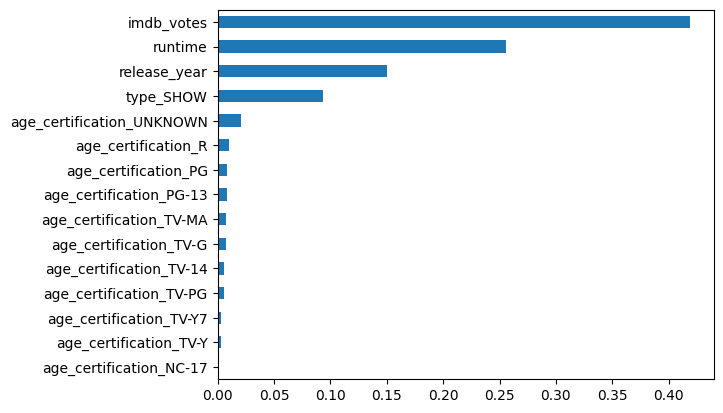

In [136]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)
importance.sort_values().plot(kind="barh")

In [144]:
movies = df_cast[df_cast["type"] == "MOVIE"]["imdb_score"]
shows = df_cast[df_cast["type"] == "SHOW"]["imdb_score"]

from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(movies, shows)

print("t-stat:", t_stat)
print("p-value:", p_value)

t-stat: -23.64007038770629
p-value: 1.574480986938148e-117


<Axes: xlabel='type', ylabel='imdb_score'>

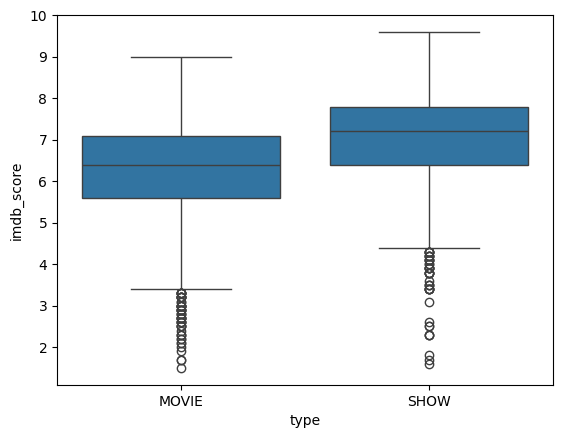

In [145]:
sns.boxplot(data=df_cast, x="type", y="imdb_score")